# Olist – Customer Segmentation (RFM + K-Means) & Sales Forecast


In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_style('whitegrid')

# --- Files Load
customers_df = pd.read_csv('olist_customers_dataset.csv')
orders_df = pd.read_csv('olist_orders_dataset.csv', parse_dates=['order_purchase_timestamp'])
order_items_df = pd.read_csv('olist_order_items_dataset.csv')
payments_df = pd.read_csv('olist_order_payments_dataset.csv')
products_df = pd.read_csv('olist_products_dataset.csv')
# Handling utf-8-sig
category_translation_df = pd.read_csv('product_category_name_translation.csv', encoding='utf-8-sig')

print('Orders by status:')
print(orders_df['order_status'].value_counts())

Orders by status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


## 1) RFM

In [ ]:
# --- Filtering Orders to be delivered ---
valid_orders = orders_df[orders_df['order_status'] == 'delivered']

# --- Order grouping  ---
order_value = payments_df.groupby('order_id', as_index=False)['payment_value'].sum()

# --- Merge: customers -> orders -> order value ---
rfm_base = (valid_orders
            .merge(customers_df[['customer_id', 'customer_unique_id']], on='customer_id', how='inner')
            .merge(order_value, on='order_id', how='inner'))
assert rfm_base['order_id'].is_unique, 'merge!'

snapshot_date = rfm_base['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = rfm_base.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda d: (snapshot_date - d.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum'),
)

print(f'Customers: {len(rfm_df):,}')
print(f"One-time buyers: {(rfm_df['Frequency'] == 1).mean():.1%}")
rfm_df.describe()

Customers: 93,357
One-time buyers: 97.0%


,Recency,Frequency,Monetary
count,93357.000000,93357.000000,93357.000000
mean,237.936673,1.033420,165.198772
std,152.584315,0.209099,226.314579
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.060000
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.560000
max,695.000000,15.000000,13664.080000


## 2) K Choosing


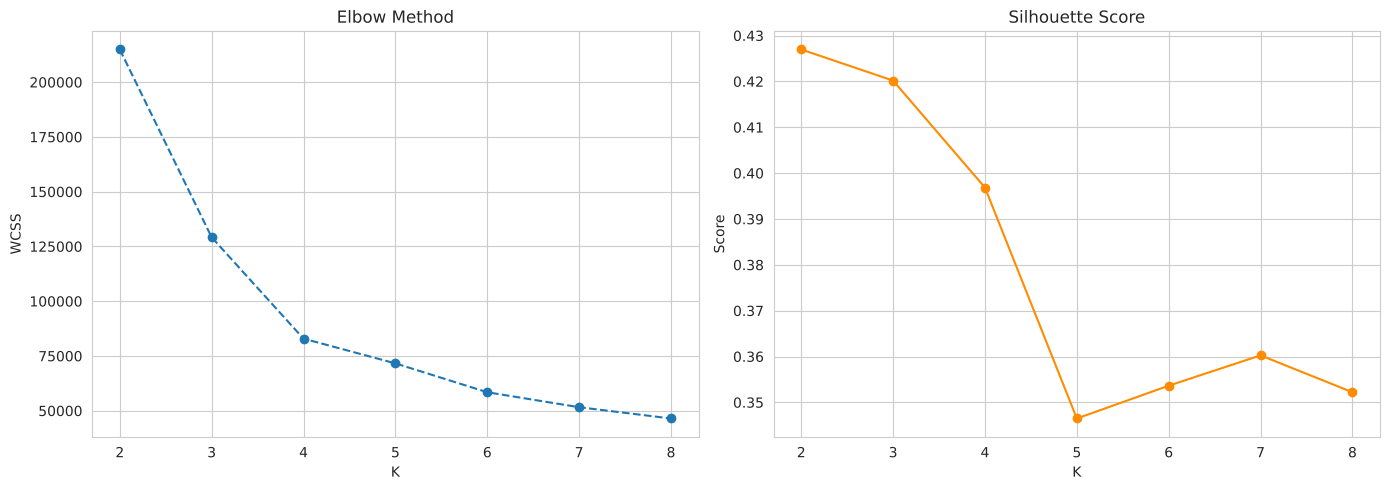

   K        WCSS  Silhouette
0  2  214930.141       0.427
1  3  129163.182       0.420
2  4   82896.888       0.397
3  5   71613.621       0.346
4  6   58433.368       0.354
5  7   51600.573       0.360
6  8   46449.143       0.352


In [ ]:
rfm_log = np.log1p(rfm_df[['Recency', 'Frequency', 'Monetary']])
rfm_scaled = StandardScaler().fit_transform(rfm_log)

ks = range(2, 9)
wcss, sil = [], []
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(rfm_scaled), size=min(10000, len(rfm_scaled)), replace=False)

for k in ks:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto').fit(rfm_scaled)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(rfm_scaled[sample_idx], km.labels_[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(ks), wcss, marker='o', linestyle='--')
axes[0].set(title='Elbow Method', xlabel='K', ylabel='WCSS')
axes[1].plot(list(ks), sil, marker='o', color='darkorange')
axes[1].set(title='Silhouette Score', xlabel='K', ylabel='Score')
plt.tight_layout(); plt.show()

print(pd.DataFrame({'K': list(ks), 'WCSS': wcss, 'Silhouette': sil}).round(3))

K-Means implemention

In [ ]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init='auto')
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled)

profile = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

def name_segments(profile):
    # Naming
    names, remaining = {}, set(profile.index)
    c = profile.loc[list(remaining), 'Frequency'].idxmax()      # High Freq
    names[c] = 'Repeat Buyers'; remaining.remove(c)
    c = profile.loc[list(remaining), 'Monetary'].idxmax()       # High Pay
    names[c] = 'Big Spenders (At Risk)'; remaining.remove(c)
    c = profile.loc[list(remaining), 'Recency'].idxmin()        # Latest Payers
    names[c] = 'New Customers'; remaining.remove(c)
    for c in remaining:                                          # Others
        names[c] = 'Lapsed Low-Value'
    return names

cluster_names = name_segments(profile)
rfm_df['Segment'] = rfm_df['Cluster'].map(cluster_names)

summary = (rfm_df.groupby('Segment')
           .agg(Customers=('Recency', 'size'), Recency=('Recency', 'mean'),
                Frequency=('Frequency', 'mean'), Monetary=('Monetary', 'mean'))
           .sort_values('Monetary', ascending=False).round(2))
summary

,Customers,Recency,Frequency,Monetary
Segment,,,,
Repeat Buyers,2801,220.29,2.11,308.59
Big Spenders (At Risk),32111,271.83,1.00,296.50
New Customers,16108,42.11,1.00,133.01
Lapsed Low-Value,42337,287.91,1.00,68.37


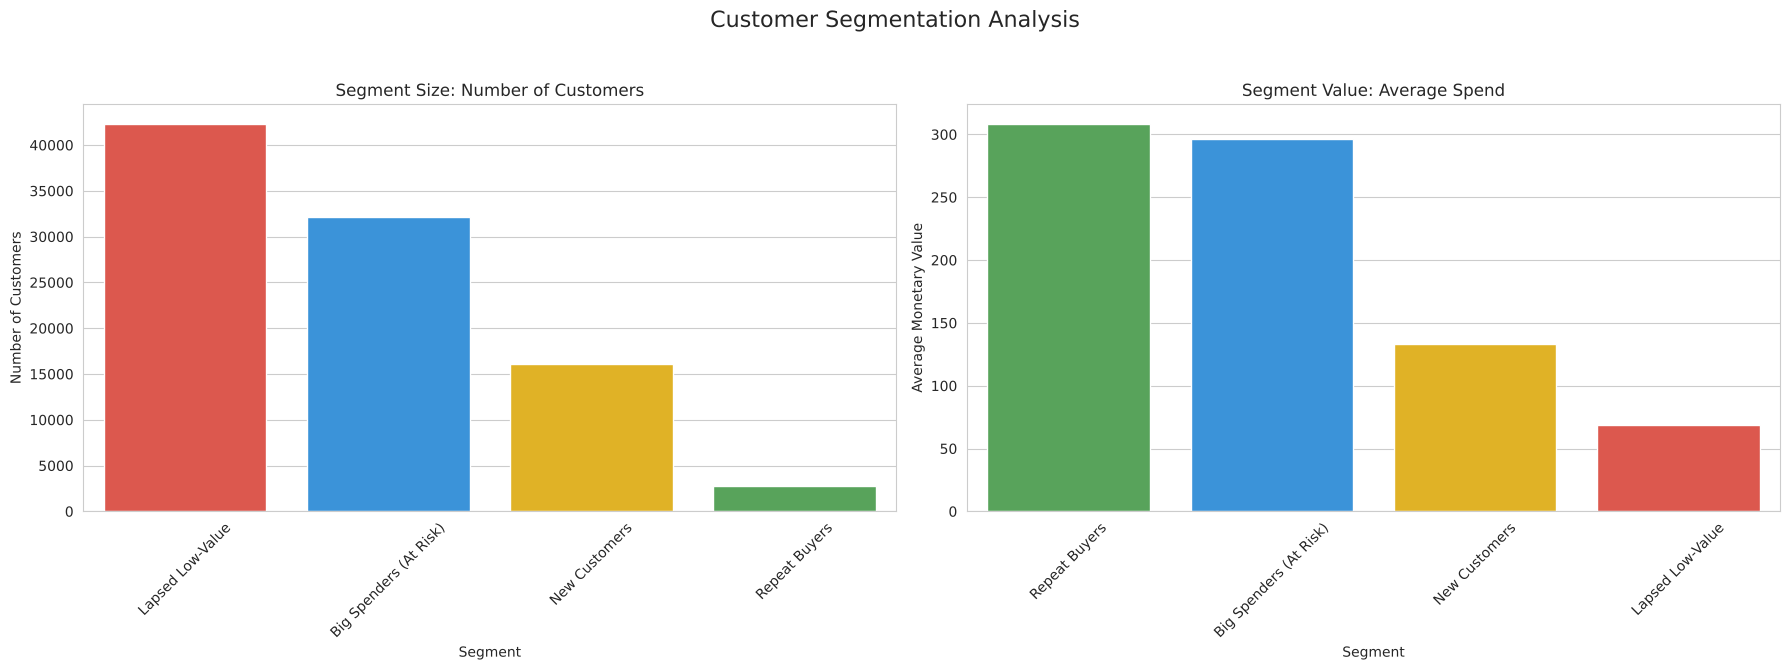

In [ ]:
segment_colors = {
    'Repeat Buyers': '#4CAF50',
    'Big Spenders (At Risk)': '#2196F3',
    'New Customers': '#FFC107',
    'Lapsed Low-Value': '#F44336',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Customer Segmentation Analysis', fontsize=16)

order = rfm_df['Segment'].value_counts().index
sns.countplot(ax=axes[0], data=rfm_df, x='Segment', hue='Segment', order=order,
              palette=segment_colors, legend=False)
axes[0].set(title='Segment Size: Number of Customers', ylabel='Number of Customers')
axes[0].tick_params(axis='x', rotation=45)

seg_value = rfm_df.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
sns.barplot(ax=axes[1], x=seg_value.index, y=seg_value.values, hue=seg_value.index,
            palette=segment_colors, legend=False)
axes[1].set(title='Segment Value: Average Spend', ylabel='Average Monetary Value')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

## 4) Sales Forecast >> The Most Selling Category

In [ ]:
items = (order_items_df
         .merge(orders_df[['order_id', 'order_status', 'order_purchase_timestamp']], on='order_id', how='inner')
         .query("order_status == 'delivered'")
         .merge(products_df[['product_id', 'product_category_name']], on='product_id', how='left')
         .merge(category_translation_df, on='product_category_name', how='left'))
items['category'] = items['product_category_name_english'].fillna(items['product_category_name']).fillna('unknown')

top_category = items.groupby('category')['price'].sum().idxmax()
print('Top category by revenue:', top_category)

monthly = (items[items['category'] == top_category]
           .set_index('order_purchase_timestamp')['price'].resample('MS').sum())

# --- before removing moths
print(monthly.round(0).to_string())

Top category by revenue: health_beauty
order_purchase_timestamp
2016-09-01       135.0
2016-10-01      3439.0
2016-11-01         0.0
2016-12-01         0.0
2017-01-01     12366.0
2017-02-01     22060.0
2017-03-01     25652.0
2017-04-01     22156.0
2017-05-01     46340.0
2017-06-01     31677.0
2017-07-01     34239.0
2017-08-01     49030.0
2017-09-01     50649.0
2017-10-01     40699.0
2017-11-01     78274.0
2017-12-01     60689.0
2018-01-01     71406.0
2018-02-01     84577.0
2018-03-01     84489.0
2018-04-01     91058.0
2018-05-01     94534.0
2018-06-01    106746.0
2018-07-01    103524.0
2018-08-01    119391.0
Freq: MS


In [ ]:

last_ts = items['order_purchase_timestamp'].max()
last_full_month = last_ts.to_period('M').to_timestamp() - pd.offsets.MonthBegin(1) \
    if last_ts.day < 28 else last_ts.to_period('M').to_timestamp()
series = monthly['2017-01-01':last_full_month]
print(f'Using {len(series)} months: {series.index[0].date()} -> {series.index[-1].date()}')

# --- Train/Test ---
test_size = 3
train, test = series[:-test_size], series[-test_size:]


best = None
for p in range(0, 3):
    for d in (1,):
        for q in range(0, 3):
            try:
                res = sm.tsa.SARIMAX(train, order=(p, d, q), trend='t',
                                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                if best is None or res.aic < best[0]:
                    best = (res.aic, (p, d, q))
            except Exception:
                pass
print('Best order by AIC:', best[1])

res_train = sm.tsa.SARIMAX(train, order=best[1], trend='t',
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
pred = res_train.get_forecast(steps=test_size).predicted_mean
mae = (test - pred).abs().mean()
mape = ((test - pred).abs() / test).mean() * 100


naive = pd.Series(train.iloc[-1], index=test.index)
naive_mae = (test - naive).abs().mean()
print(f'ARIMA  MAE: {mae:,.0f}  | MAPE: {mape:.1f}%')
print(f'Naive  MAE: {naive_mae:,.0f}')

Using 20 months: 2017-01-01 -> 2018-08-01


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


Best order by AIC: (2, 1, 2)
ARIMA  MAE: 4,498  | MAPE: 4.2%
Naive  MAE: 15,353


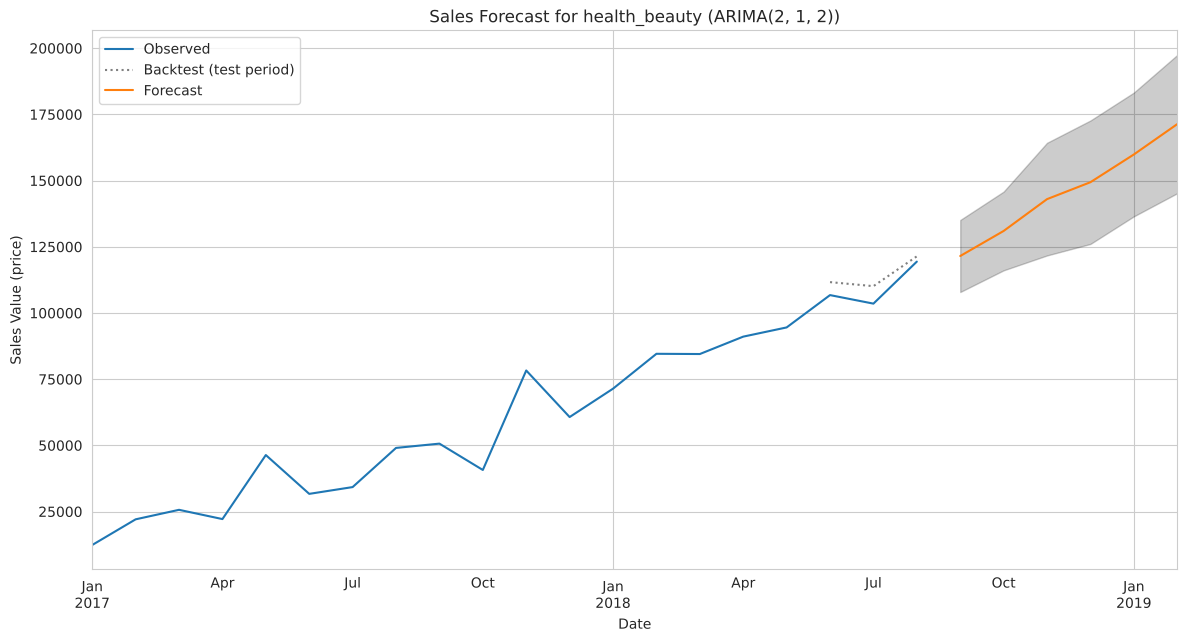

,forecast
2018-09-01,121507.0
2018-10-01,130966.0
2018-11-01,142988.0
2018-12-01,149378.0
2019-01-01,159852.0
2019-02-01,171319.0


In [ ]:
# --- Final Forecast
final = sm.tsa.SARIMAX(series, order=best[1], trend='t',
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
steps = 6
fc = final.get_forecast(steps=steps)
fc_mean, ci = fc.predicted_mean, fc.conf_int()
ci.iloc[:, 0] = ci.iloc[:, 0].clip(lower=0)   # No Negative sales

fig, ax = plt.subplots(figsize=(14, 7))
series.plot(ax=ax, label='Observed')
pred.plot(ax=ax, label='Backtest (test period)', linestyle=':', color='gray')
fc_mean.plot(ax=ax, label='Forecast', color='tab:orange')
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color='k', alpha=.2)
ax.set(xlabel='Date', ylabel='Sales Value (price)',
       title=f'Sales Forecast for {top_category} (ARIMA{best[1]})')
ax.legend(); ax.grid(True); plt.show()

fc_mean.round(0).to_frame('forecast')